In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv(r"C:\Users\BHUPATHI NADAR\OneDrive\Desktop\Main_project\MLSC-Task\Data\updated_data.csv")

In [3]:
df.head()

,question,documents,response,sentence_support_information,label
0,What role does T-cell count play in severe hum...,['Title: Emergent severe acute respiratory dis...,The T-cell count plays a crucial role in sever...,[{'explanation': 'This sentence is supported b...,GROUNDED
1,What is MVO?,['Title: Gene Knockdowns in Adult Animals: PPM...,MVO is not defined or mentioned in the provide...,[{'explanation': 'The sentence correctly state...,GROUNDED
2,What have sero-surveys of MERS virus found?,"['Title: MERS coronavirus: diagnostics, epidem...",Sero-surveys of MERS virus found no sign of ME...,[{'explanation': 'This sentence is partly supp...,PARTIALLY_GROUNDED
3,How were untreated MDA-MB-231 cells labeled?,['Title: Kinome-Wide siRNA Screening Identifie...,The untreated MDA-MB-231 cells were labeled wi...,[{'explanation': 'The sentence is fully suppor...,GROUNDED
4,What is the number of inhabitants of Reunion I...,['Title: Pandemic Influenza Due to pH1N1/2009 ...,"Reunion Island has a population of 850,000 inh...",[{'explanation': 'This sentence claims that Re...,GROUNDED


In [4]:
X = df.drop(["label","sentence_support_information"],axis=1)
y = df["label"]

# Method 1 Using simple Model

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42)

In [6]:
def documents_to_text(documents):
    if isinstance(documents, (list, tuple, np.ndarray)):
        return " ".join(map(str, documents))
    return str(documents)


X_train_text = (
    X_train["question"].fillna("") + " " +
    X_train["documents"].apply(documents_to_text) + " " +
    X_train["response"].fillna("")
)

X_test_text = (
    X_test["question"].fillna("") + " " +
    X_test["documents"].apply(documents_to_text) + " " +
    X_test["response"].fillna("")
)

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [8]:
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2)
)

X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf = tfidf.transform(X_test_text)

In [9]:
print("y_train labels:")
print(y_train.value_counts())

print("\ny_test labels:")
print(y_test.value_counts())

y_train labels:
label
GROUNDED              37738
HALLUCINATED          32478
PARTIALLY_GROUNDED     6086
Name: count, dtype: int64

y_test labels:
label
GROUNDED              9546
HALLUCINATED          8098
PARTIALLY_GROUNDED    1432
Name: count, dtype: int64


Accuracy: 0.7927762633675823
Macro F1: 0.6045052014776672
                    precision    recall  f1-score   support

          GROUNDED       0.75      0.92      0.83      9546
      HALLUCINATED       0.88      0.76      0.82      8098
PARTIALLY_GROUNDED       0.38      0.11      0.17      1432

          accuracy                           0.79     19076
         macro avg       0.67      0.60      0.60     19076
      weighted avg       0.78      0.79      0.77     19076



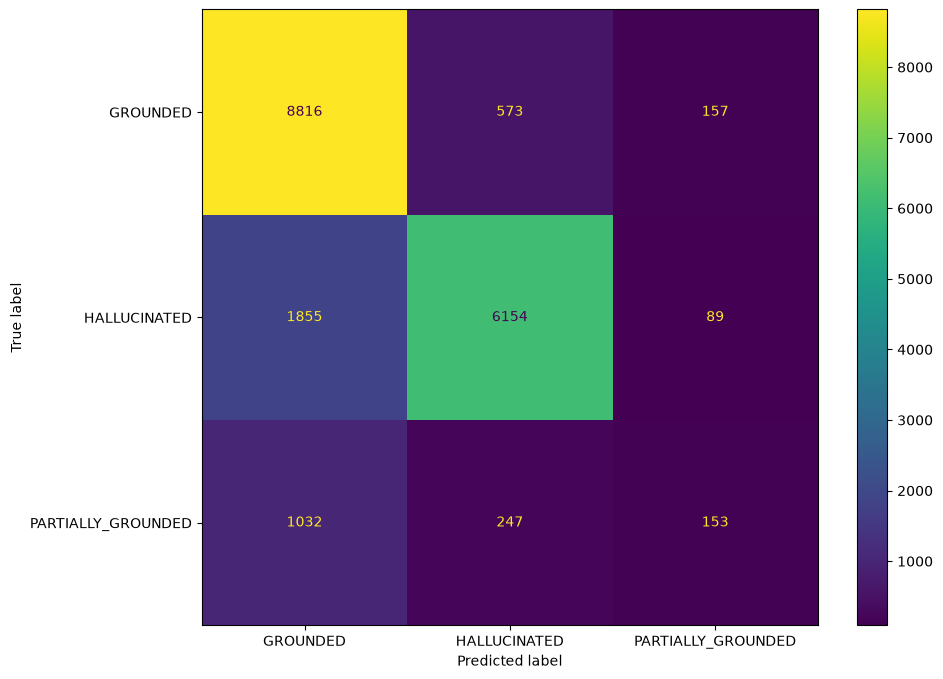

In [10]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000
)

model.fit(X_train_tfidf, y_train)
y_pred = model.predict(X_test_tfidf)

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    ConfusionMatrixDisplay
)

print("Accuracy:", accuracy_score(y_test, y_pred))

print(
    "Macro F1:",
    f1_score(
        y_test,
        y_pred,
        average="macro"
    )
)

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(10, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model.classes_
)

disp.plot(ax=ax)

plt.show()

# Method 2 Using Stratify to y

Accuracy: 0.7892639966449989
Macro F1: 0.5990650790235429
                    precision    recall  f1-score   support

          GROUNDED       0.75      0.92      0.83      9457
      HALLUCINATED       0.87      0.77      0.82      8115
PARTIALLY_GROUNDED       0.38      0.10      0.15      1504

          accuracy                           0.79     19076
         macro avg       0.67      0.59      0.60     19076
      weighted avg       0.77      0.79      0.77     19076



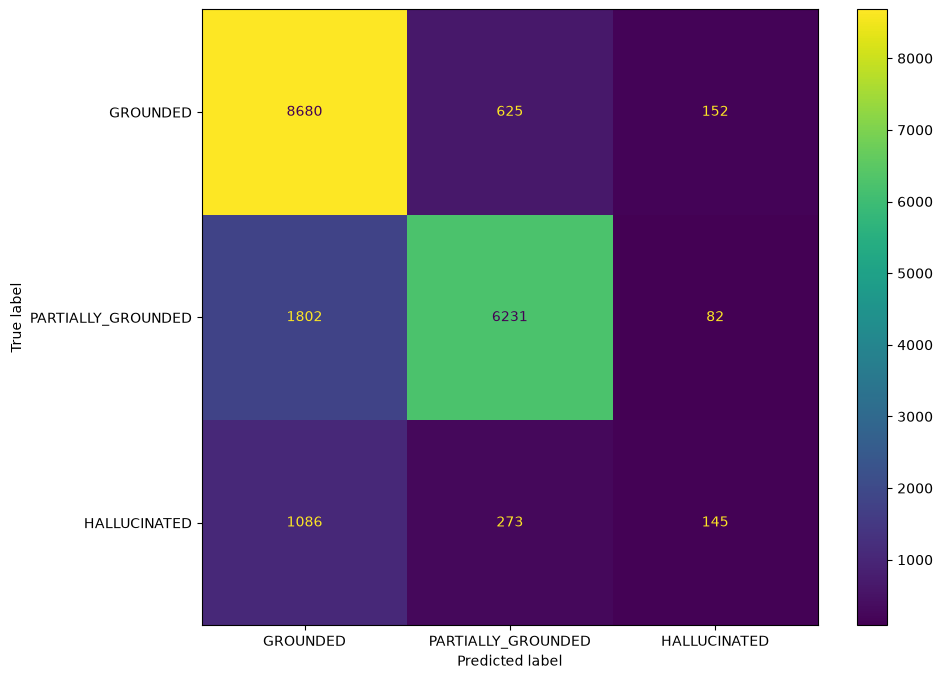

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y)



model = LogisticRegression(
    max_iter=1000
)

def documents_to_text(documents):
    if isinstance(documents, (list, tuple, np.ndarray)):
        return " ".join(map(str, documents))
    return str(documents)


X_train_text = (
    X_train["question"].fillna("") + " " +
    X_train["documents"].apply(documents_to_text) + " " +
    X_train["response"].fillna("")
)

X_test_text = (
    X_test["question"].fillna("") + " " +
    X_test["documents"].apply(documents_to_text) + " " +
    X_test["response"].fillna("")
)

X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf = tfidf.transform(X_test_text)

model.fit(X_train_tfidf, y_train)

y_pred = model.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, y_pred))

print(
    "Macro F1:",
    f1_score(
        y_test,
        y_pred,
        average="macro"
    )
)

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(10, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["GROUNDED", "PARTIALLY_GROUNDED", "HALLUCINATED"]
)

disp.plot(ax=ax)

plt.show()

# Method 3 using  class_weight="balanced" and startify to y

Accuracy: 0.7164499895156218
Macro F1: 0.6394916080917648
                    precision    recall  f1-score   support

          GROUNDED       0.81      0.70      0.75      9457
      HALLUCINATED       0.88      0.74      0.81      8115
PARTIALLY_GROUNDED       0.24      0.67      0.36      1504

          accuracy                           0.72     19076
         macro avg       0.65      0.70      0.64     19076
      weighted avg       0.80      0.72      0.75     19076



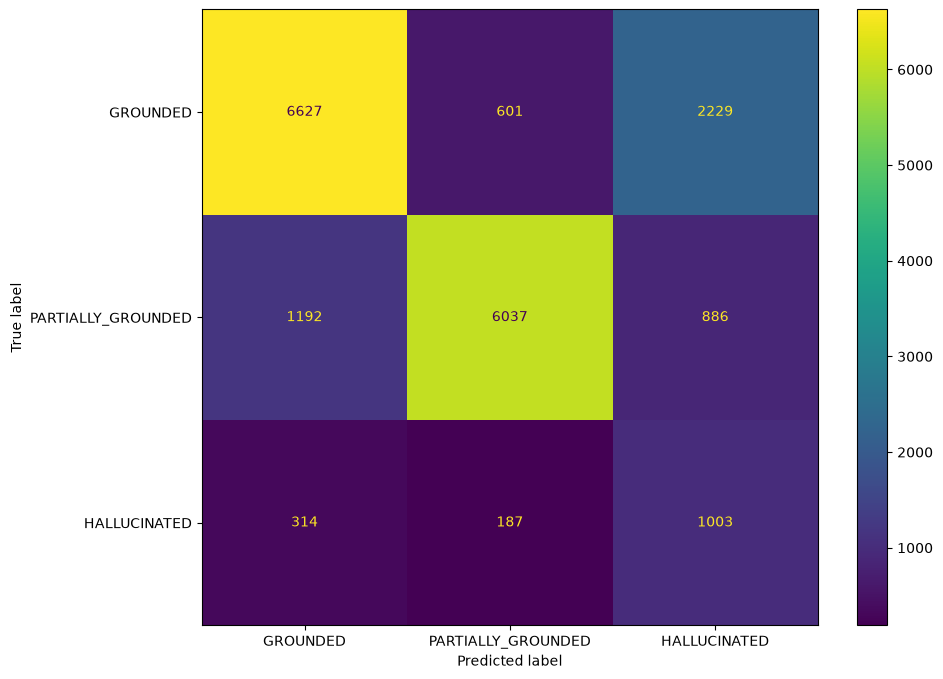

In [12]:
model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

model.fit(X_train_tfidf, y_train)

y_pred = model.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, y_pred))

print(
    "Macro F1:",
    f1_score(
        y_test,
        y_pred,
        average="macro"
    )
)

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(10, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["GROUNDED", "PARTIALLY_GROUNDED", "HALLUCINATED"]
)

disp.plot(ax=ax)

plt.show()

# Using Smote

In [13]:
from imblearn.over_sampling import SMOTE

In [14]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_tfidf,
    y_train
)

In [15]:
print("Before:")
print(y_train.value_counts())

print("\nAfter:")
print(pd.Series(y_train_smote).value_counts())

Before:
label
GROUNDED              37827
HALLUCINATED          32461
PARTIALLY_GROUNDED     6014
Name: count, dtype: int64

After:
label
GROUNDED              37827
HALLUCINATED          37827
PARTIALLY_GROUNDED    37827
Name: count, dtype: int64


Accuracy: 0.730236946949046
Macro F1: 0.6439462234696007
                    precision    recall  f1-score   support

          GROUNDED       0.82      0.73      0.77      9457
      HALLUCINATED       0.88      0.76      0.81      8115
PARTIALLY_GROUNDED       0.25      0.60      0.35      1504

          accuracy                           0.73     19076
         macro avg       0.65      0.69      0.64     19076
      weighted avg       0.80      0.73      0.76     19076



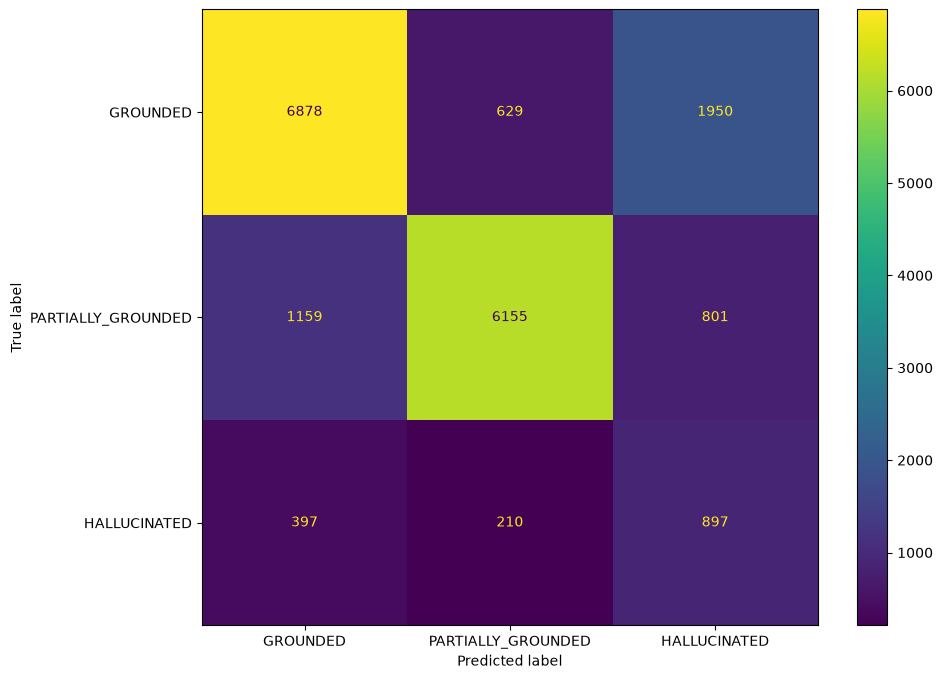

In [16]:
model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

model.fit(X_train_smote, y_train_smote)

y_pred = model.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, y_pred))

print(
    "Macro F1:",
    f1_score(
        y_test,
        y_pred,
        average="macro"
    )
)

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(10, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["GROUNDED", "PARTIALLY_GROUNDED", "HALLUCINATED"]
)

disp.plot(ax=ax)

plt.show()